# LSTM for IMDB Sentiment

This notebook explains recurrent networks, LSTMs, and GRUs, then trains a compact PyTorch LSTM on the same order-preserving IMDB representation used by the earlier convolutional experiment.

## Recurrent units and hidden state

A recurrent unit processes one position at a time while carrying a **hidden state** forward. At step `t`, the unit combines the current input with the state from step `t - 1` to produce a new state. The same parameters are reused at every position, so the hidden state acts as a learned summary of the sequence seen so far.

RNNs process ordered data whose positions are related, including text, speech, sensor readings, and time series. Sequence length can vary, and the order matters: reversing a sentence or a time series generally changes its meaning.

A vanilla RNN repeatedly multiplies information and gradients through the same transition. Over long sequences, gradients can shrink toward zero or grow without bound, making distant dependencies difficult to learn. Its single state also has no explicit mechanism for deciding what to remember or forget.

An **LSTM** adds a cell state and input, forget, and output gates. The gated path lets useful information and gradients travel across more steps. A **GRU** combines the cell and hidden state and uses update and reset gates, so it is simpler and usually has fewer parameters. Both reduce the long-range optimization problem, although neither guarantees that every long dependency will be learned.

## Experiment design

Reviews that become identical after preprocessing and 256-token truncation are deduplicated before a seeded stratified 60/20/20 train/validation/test split. The 20,000-token vocabulary is learned from training reviews only. The final valid recurrent output represents each review, so right-padding cannot replace its learned sequence summary.

Architecture, optimizer, three-epoch budget, and the 0.5 threshold are fixed before training. The checkpoint with the lowest validation loss is retained, and the test set remains untouched until that choice is complete.

In [1]:
from collections import Counter
from itertools import chain
from pathlib import Path
import copy
import os
import shutil
import subprocess
import sys
import time

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
import torch
from torch import nn

SEED = 42
MAX_SEQUENCE_LENGTH = 256
MAX_VOCABULARY_SIZE = 20_000
PAD_ID = 0
UNKNOWN_ID = 1
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(8, os.cpu_count() or 1))
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gpu_name = "Not detected"
if shutil.which("nvidia-smi"):
    query = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        capture_output=True,
        text=True,
        check=True,
    )
    gpu_name = query.stdout.strip()

current_path = Path.cwd().resolve()
repository_root = next(
    (
        path
        for path in (current_path, *current_path.parents)
        if (path / "phase-1-machine-learning-nlp").is_dir()
    ),
    None,
)
if repository_root is None:
    raise FileNotFoundError("Could not locate the repository root.")

phase_1 = repository_root / "phase-1-machine-learning-nlp"
part_02 = phase_1 / "02-preprocessing-tokenization"
sys.path.insert(0, str(part_02 / "src"))

from preprocessor import preprocess_text
from tokenizer import regex_tokenize

imdb_path = part_02 / "data" / "IMDB Dataset.csv"
if not imdb_path.exists():
    raise FileNotFoundError(
        "Download the IMDB 50K Reviews dataset and place 'IMDB Dataset.csv' in "
        f"{imdb_path.parent}. The CSV is intentionally ignored by Git."
    )

imdb = pd.read_csv(imdb_path).dropna(subset=["review", "sentiment"])
imdb["label"] = imdb["sentiment"].map({"negative": 0, "positive": 1})
if imdb["label"].isna().any():
    raise ValueError("Sentiment labels must be either 'negative' or 'positive'.")


def model_tokens(review):
    cleaned = preprocess_text(
        str(review), remove_stopwords=False, apply_stemming=False
    )
    return [
        token
        for token in regex_tokenize(cleaned)
        if token.isalpha() and len(token) >= 2
    ]


imdb["tokens"] = imdb["review"].map(model_tokens)
imdb["model_visible_text"] = (
    imdb["tokens"].str[:MAX_SEQUENCE_LENGTH].str.join(" ")
)
if imdb["model_visible_text"].eq("").any():
    raise ValueError("Preprocessing produced an empty review.")
if imdb.groupby("model_visible_text")["label"].nunique().gt(1).any():
    raise ValueError(
        "Reviews identical after preprocessing and truncation have conflicting labels."
    )

original_size = len(imdb)
imdb = imdb.drop_duplicates(subset="model_visible_text").reset_index(drop=True)
development, test = train_test_split(
    imdb,
    test_size=0.20,
    random_state=SEED,
    stratify=imdb["label"],
)
train, validation = train_test_split(
    development,
    test_size=0.25,
    random_state=SEED,
    stratify=development["label"],
)

split_frames = {"train": train, "validation": validation, "test": test}
for left, right in (("train", "validation"), ("train", "test"), ("validation", "test")):
    assert set(split_frames[left]["model_visible_text"]).isdisjoint(
        split_frames[right]["model_visible_text"]
    )

split_summary = pd.DataFrame(
    {
        "reviews": [len(train), len(validation), len(test)],
        "positive proportion": [
            train["label"].mean(),
            validation["label"].mean(),
            test["label"].mean(),
        ],
    },
    index=["train", "validation", "test"],
)

print(f"PyTorch: {torch.__version__}")
print(f"System GPU: {gpu_name}")
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
print(f"Selected device: {device}")
print(f"Reviews retained: {len(imdb):,} ({original_size - len(imdb):,} duplicates removed)")
print("Model-visible review overlap across splits: 0")
display(split_summary.style.format({"positive proportion": "{:.4f}"}))

PyTorch: 2.13.0+cpu
System GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
PyTorch CUDA available: False
Selected device: cpu
Reviews retained: 49,577 (423 duplicates removed)
Model-visible review overlap across splits: 0


,reviews,positive proportion
train,29745,0.5019
validation,9916,0.5019
test,9916,0.5019


## Training-only vocabulary and fixed-length sequences

Index 0 is padding and index 1 represents tokens outside the training vocabulary. Frequency counts use only training reviews. Each review is right-padded or truncated to 256 positions. Its true retained length identifies the last valid recurrent output, so padding cannot replace the review representation. The three-epoch budget keeps sequential training feasible on the available CPU-only runtime.

In [2]:
token_counts = Counter(chain.from_iterable(train["tokens"]))
vocabulary_terms = [
    token
    for token, count in sorted(
        token_counts.items(), key=lambda item: (-item[1], item[0])
    )
    if count >= 2
][:(MAX_VOCABULARY_SIZE - 2)]
vocabulary = {
    token: index + 2 for index, token in enumerate(vocabulary_terms)
}


def encode_reviews(token_lists):
    encoded = np.full(
        (len(token_lists), MAX_SEQUENCE_LENGTH), PAD_ID, dtype=np.int32
    )
    lengths = np.empty(len(token_lists), dtype=np.int64)
    unknown_tokens = 0
    retained_tokens = 0
    for row, tokens in enumerate(token_lists):
        retained = tokens[:MAX_SEQUENCE_LENGTH]
        token_ids = [vocabulary.get(token, UNKNOWN_ID) for token in retained]
        encoded[row, :len(token_ids)] = token_ids
        lengths[row] = len(token_ids)
        unknown_tokens += sum(token_id == UNKNOWN_ID for token_id in token_ids)
        retained_tokens += len(token_ids)
    return encoded, lengths, unknown_tokens / retained_tokens


encoding_start = time.perf_counter()
train_ids, train_lengths, train_unknown_rate = encode_reviews(train["tokens"].tolist())
validation_ids, validation_lengths, validation_unknown_rate = encode_reviews(
    validation["tokens"].tolist()
)
test_ids, test_lengths, test_unknown_rate = encode_reviews(test["tokens"].tolist())
encoded_splits = {
    "train": train_ids,
    "validation": validation_ids,
    "test": test_ids,
}
encoded_rows = {
    name: {row.tobytes() for row in rows}
    for name, rows in encoded_splits.items()
}
for left, right in (("train", "validation"), ("train", "test"), ("validation", "test")):
    assert encoded_rows[left].isdisjoint(encoded_rows[right])
encoding_seconds = time.perf_counter() - encoding_start

train_labels = train["label"].to_numpy(dtype=np.float32)
validation_labels = validation["label"].to_numpy(dtype=np.float32)
test_labels = test["label"].to_numpy(dtype=np.float32)

sequence_summary = pd.DataFrame(
    {
        "mean retained length": [
            train_lengths.mean(), validation_lengths.mean(), test_lengths.mean()
        ],
        "truncated proportion": [
            np.mean(train["tokens"].str.len() > MAX_SEQUENCE_LENGTH),
            np.mean(validation["tokens"].str.len() > MAX_SEQUENCE_LENGTH),
            np.mean(test["tokens"].str.len() > MAX_SEQUENCE_LENGTH),
        ],
        "unknown-token rate": [
            train_unknown_rate, validation_unknown_rate, test_unknown_rate
        ],
    },
    index=["train", "validation", "test"],
)

print(f"Vocabulary size including special tokens: {len(vocabulary) + 2:,}")
print(f"Encoded training shape: {train_ids.shape}")
print(f"Sequence encoding time: {encoding_seconds:.2f} seconds")
print("Encoded sequence overlap across splits: 0")
display(sequence_summary.style.format("{:.4f}"))
assert train_lengths.min() >= 1
assert set(vocabulary).isdisjoint({"<pad>", "<unknown>"})

Vocabulary size including special tokens: 20,000
Encoded training shape: (29745, 256)
Sequence encoding time: 1.37 seconds
Encoded sequence overlap across splits: 0


,mean retained length,truncated proportion,unknown-token rate
train,170.5494,0.2562,0.0407
validation,170.3801,0.2603,0.0430
test,169.6033,0.2566,0.0430


## LSTM classifier

The embedding layer maps token IDs to 64-dimensional vectors. A one-layer, unidirectional LSTM produces a 64-dimensional output at every valid position, dropout regularizes that representation, and a linear layer emits one sentiment logit. Xavier initialization is used for input-to-hidden matrices, orthogonal initialization for recurrent matrices, and the forget-gate bias starts at one so the initial dynamics do not immediately erase the cell state.

In [3]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocabulary_size):
        super().__init__()
        self.embedding = nn.Embedding(
            vocabulary_size, 64, padding_idx=PAD_ID
        )
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
        )
        self.dropout = nn.Dropout(0.30)
        self.output = nn.Linear(64, 1)
        nn.init.uniform_(self.embedding.weight, -0.05, 0.05)
        with torch.no_grad():
            self.embedding.weight[PAD_ID].zero_()
        for name, parameter in self.lstm.named_parameters():
            if "weight_ih" in name:
                nn.init.xavier_uniform_(parameter)
            elif "weight_hh" in name:
                nn.init.orthogonal_(parameter)
            else:
                nn.init.zeros_(parameter)
                parameter.data[64:128].fill_(1.0)
        nn.init.xavier_uniform_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def forward(self, token_ids, lengths):
        embedded = self.embedding(token_ids)
        sequence_outputs, _ = self.lstm(embedded)
        batch_indices = torch.arange(token_ids.shape[0], device=token_ids.device)
        last_indices = lengths.to(token_ids.device) - 1
        representation = self.dropout(
            sequence_outputs[batch_indices, last_indices]
        )
        return self.output(representation).squeeze(1)


model = SentimentLSTM(len(vocabulary) + 2).to(device)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
example_ids = torch.from_numpy(train_ids[:4]).long().to(device)
example_lengths = torch.from_numpy(train_lengths[:4])
with torch.no_grad():
    example_logits = model(example_ids, example_lengths)

print(model)
print(f"Trainable parameters: {parameter_count:,}")
print(f"Example output shape: {tuple(example_logits.shape)}")
assert example_logits.shape == (4,)
assert torch.count_nonzero(model.embedding.weight[PAD_ID]).item() == 0

SentimentLSTM(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (output): Linear(in_features=64, out_features=1, bias=True)
)
Trainable parameters: 1,313,345
Example output shape: (4,)


## Training and validation checkpointing

Binary cross-entropy with logits provides a numerically stable objective. AdamW trains the model for three fixed epochs, and a total gradient-norm ceiling of 1.0 limits exploding updates. Mini-batches are shuffled reproducibly. Validation loss selects one in-memory checkpoint before the test set is evaluated.

Epoch  1/3 | train loss 0.5750 | validation loss 0.4332 | validation accuracy 0.8135 | validation F1 0.8287


Epoch  2/3 | train loss 0.3185 | validation loss 0.3462 | validation accuracy 0.8510 | validation F1 0.8622


Epoch  3/3 | train loss 0.2194 | validation loss 0.3273 | validation accuracy 0.8699 | validation F1 0.8674


,train loss,validation loss,validation accuracy,validation F1
epoch,,,,
1,0.5750,0.4332,0.8135,0.8287
2,0.3185,0.3462,0.8510,0.8622
3,0.2194,0.3273,0.8699,0.8674


Selected epoch: 3
Training and validation time: 87.49 seconds
Maximum pre-clipping gradient norm: 61.7087
Updates clipped: 308


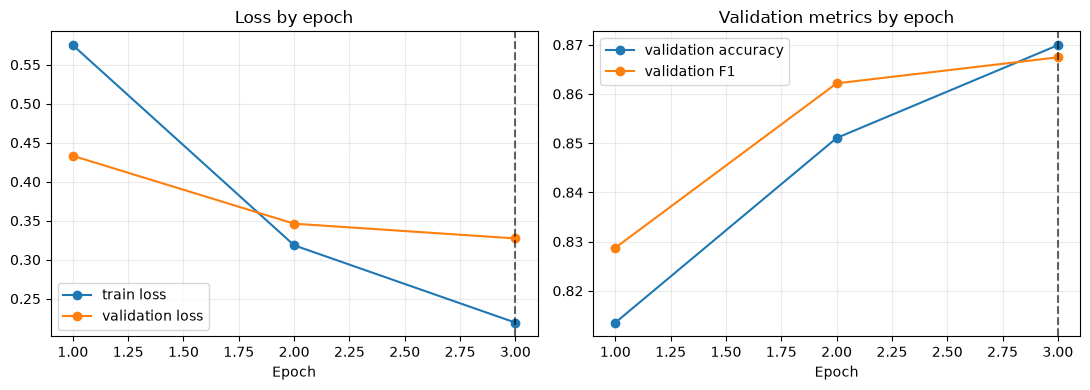

In [4]:
def tensors_for_batch(token_ids, lengths, labels, indices):
    batch_ids = torch.from_numpy(token_ids[indices]).long().to(device)
    batch_lengths = torch.from_numpy(lengths[indices])
    batch_labels = torch.from_numpy(labels[indices]).to(device)
    return batch_ids, batch_lengths, batch_labels


def evaluate_model(model, token_ids, lengths, labels, batch_size):
    model.eval()
    total_loss = 0.0
    probabilities = []
    with torch.no_grad():
        for start in range(0, len(labels), batch_size):
            indices = np.arange(start, min(start + batch_size, len(labels)))
            batch_ids, batch_lengths, batch_labels = tensors_for_batch(
                token_ids, lengths, labels, indices
            )
            logits = model(batch_ids, batch_lengths)
            loss = loss_function(logits, batch_labels)
            if not torch.isfinite(loss):
                raise FloatingPointError("Evaluation produced a non-finite loss.")
            total_loss += loss.item() * len(indices)
            probabilities.append(torch.sigmoid(logits).cpu().numpy())
    return total_loss / len(labels), np.concatenate(probabilities)


batch_size = 256
epochs = 3
learning_rate = 1e-3
gradient_norm_ceiling = 1.0
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(
    model.parameters(), lr=learning_rate, weight_decay=1e-4
)
history = []
best_state = None
best_epoch = None
best_validation_loss = float("inf")
maximum_gradient_norm = 0.0
clipped_updates = 0
training_start = time.perf_counter()

for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss = 0.0
    shuffled_indices = np.random.default_rng(SEED + epoch).permutation(
        len(train_labels)
    )
    for start in range(0, len(train_labels), batch_size):
        indices = shuffled_indices[start:start + batch_size]
        batch_ids, batch_lengths, batch_labels = tensors_for_batch(
            train_ids, train_lengths, train_labels, indices
        )
        optimizer.zero_grad()
        logits = model(batch_ids, batch_lengths)
        loss = loss_function(logits, batch_labels)
        if not torch.isfinite(loss):
            raise FloatingPointError("Training produced a non-finite loss.")
        loss.backward()
        gradient_norm = torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            gradient_norm_ceiling,
            error_if_nonfinite=True,
        )
        gradient_norm_value = float(gradient_norm)
        maximum_gradient_norm = max(maximum_gradient_norm, gradient_norm_value)
        clipped_updates += gradient_norm_value > gradient_norm_ceiling
        optimizer.step()
        epoch_loss += loss.item() * len(indices)

    train_loss = epoch_loss / len(train_labels)
    validation_loss, validation_probabilities = evaluate_model(
        model,
        validation_ids,
        validation_lengths,
        validation_labels,
        batch_size,
    )
    validation_predictions = (validation_probabilities >= 0.5).astype(int)
    row = {
        "epoch": epoch,
        "train loss": train_loss,
        "validation loss": validation_loss,
        "validation accuracy": accuracy_score(
            validation_labels, validation_predictions
        ),
        "validation F1": f1_score(
            validation_labels, validation_predictions
        ),
    }
    history.append(row)
    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
    print(
        f"Epoch {epoch:>2}/{epochs} | train loss {train_loss:.4f} | "
        f"validation loss {validation_loss:.4f} | "
        f"validation accuracy {row['validation accuracy']:.4f} | "
        f"validation F1 {row['validation F1']:.4f}"
    )

training_seconds = time.perf_counter() - training_start
model.load_state_dict(best_state)
history_frame = pd.DataFrame(history).set_index("epoch")
display(history_frame.style.format("{:.4f}"))
print(f"Selected epoch: {best_epoch}")
print(f"Training and validation time: {training_seconds:.2f} seconds")
print(f"Maximum pre-clipping gradient norm: {maximum_gradient_norm:.4f}")
print(f"Updates clipped: {clipped_updates}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
history_frame[["train loss", "validation loss"]].plot(
    ax=axes[0], marker="o"
)
history_frame[["validation accuracy", "validation F1"]].plot(
    ax=axes[1], marker="o"
)
for axis in axes:
    axis.axvline(best_epoch, color="black", linestyle="--", alpha=0.6)
    axis.grid(alpha=0.25)
    axis.set_xlabel("Epoch")
axes[0].set_title("Loss by epoch")
axes[1].set_title("Validation metrics by epoch")
plt.tight_layout()
plt.show()

## Held-out test evaluation

The validation-selected checkpoint is now fixed and evaluated once on the untouched test split. Accuracy and F1 summarize overall classification, precision and recall expose error balance, and ROC AUC evaluates probability ranking independently of the 0.5 threshold.

,test score
loss,0.3085
accuracy,0.8728
precision,0.8895
recall,0.8525
F1,0.8706
ROC AUC,0.9458


              precision    recall  f1-score   support

    negative     0.8574    0.8933    0.8750      4939
    positive     0.8895    0.8525    0.8706      4977

    accuracy                         0.8728      9916
   macro avg     0.8734    0.8729    0.8728      9916
weighted avg     0.8735    0.8728    0.8728      9916



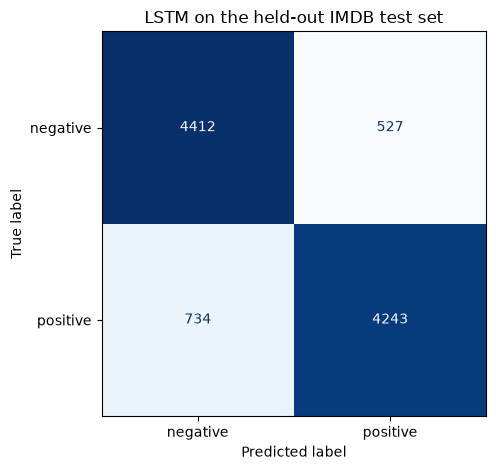

In [5]:
test_loss, test_probabilities = evaluate_model(
    model, test_ids, test_lengths, test_labels, batch_size
)
test_predictions = (test_probabilities >= 0.5).astype(int)
test_metrics = pd.Series(
    {
        "loss": test_loss,
        "accuracy": accuracy_score(test_labels, test_predictions),
        "precision": precision_score(test_labels, test_predictions),
        "recall": recall_score(test_labels, test_predictions),
        "F1": f1_score(test_labels, test_predictions),
        "ROC AUC": roc_auc_score(test_labels, test_probabilities),
    },
    name="test score",
).to_frame()

display(test_metrics.style.format("{:.4f}"))
print(classification_report(
    test_labels,
    test_predictions,
    target_names=["negative", "positive"],
    digits=4,
))

ConfusionMatrixDisplay.from_predictions(
    test_labels,
    test_predictions,
    display_labels=["negative", "positive"],
    cmap="Blues",
    colorbar=False,
)
plt.title("LSTM on the held-out IMDB test set")
plt.tight_layout()
plt.show()

assert np.isfinite(test_metrics.to_numpy()).all()
assert len(test_predictions) == len(test_labels)

In [6]:
selected_validation = history_frame.loc[best_epoch]
final_training_loss = history_frame.iloc[-1]["train loss"]
test_scores = test_metrics["test score"]
display(Markdown(
    f'''## Observations

The LSTM selected epoch **{best_epoch}** with validation loss **{selected_validation['validation loss']:.4f}**, validation accuracy **{selected_validation['validation accuracy']:.4f}**, and validation F1 **{selected_validation['validation F1']:.4f}**. Training loss fell to **{final_training_loss:.4f}**, while validation loss also improved through the third epoch. This fixed budget did not show a validation-loss reversal, so a longer predeclared run could still help.

The retained checkpoint achieved held-out test accuracy **{test_scores['accuracy']:.4f}**, precision **{test_scores['precision']:.4f}**, recall **{test_scores['recall']:.4f}**, F1 **{test_scores['F1']:.4f}**, and ROC AUC **{test_scores['ROC AUC']:.4f}**. These results measure this compact, untuned recurrent model rather than claiming that an LSTM is universally preferable to the earlier CNN or TF-IDF classifiers.

The training-only vocabulary left **{test_unknown_rate:.2%}** of retained test tokens unknown, while 256-token truncation affected **{np.mean(test['tokens'].str.len() > MAX_SEQUENCE_LENGTH):.2%}** of test reviews. The final hidden state can preserve ordered context, but truncation and compression into one vector still limit very long reviews.

The maximum pre-clipping gradient norm was **{maximum_gradient_norm:.4f}**, and **{clipped_updates}** updates exceeded the **{gradient_norm_ceiling:.1f}** ceiling. The detected system GPU was **{gpu_name}**, but PyTorch exposed CUDA as **{torch.cuda.is_available()}**. The run therefore used **{device}** and completed three training and validation epochs in **{training_seconds:.2f} seconds**.'''
))

## Observations

The LSTM selected epoch **3** with validation loss **0.3273**, validation accuracy **0.8699**, and validation F1 **0.8674**. Training loss fell to **0.2194**, while validation loss also improved through the third epoch. This fixed budget did not show a validation-loss reversal, so a longer predeclared run could still help.

The retained checkpoint achieved held-out test accuracy **0.8728**, precision **0.8895**, recall **0.8525**, F1 **0.8706**, and ROC AUC **0.9458**. These results measure this compact, untuned recurrent model rather than claiming that an LSTM is universally preferable to the earlier CNN or TF-IDF classifiers.

The training-only vocabulary left **4.30%** of retained test tokens unknown, while 256-token truncation affected **25.66%** of test reviews. The final hidden state can preserve ordered context, but truncation and compression into one vector still limit very long reviews.

The maximum pre-clipping gradient norm was **61.7087**, and **308** updates exceeded the **1.0** ceiling. The detected system GPU was **NVIDIA GeForce RTX 3050 Ti Laptop GPU**, but PyTorch exposed CUDA as **False**. The run therefore used **cpu** and completed three training and validation epochs in **87.49 seconds**.